In [1]:
import pandas as pd
import numpy as np 

In [2]:
df = pd.read_csv("../Dataset/Sample_dataset.csv")

### Data Exploration

In [3]:
df.head()

,OrderID,OrderDate,Product,Category,Quantity,Sales,Region,PaymentMethod,OrderStatus
0,1,1/2/2025,Mouse,Electronics,5,3778.0,South,UPI,Completed
1,2,1/3/2025,Phone,electronics,9,13934.0,North,Credit Card,Pending
2,3,1/4/2025,Keyboard,Electronics,1,4665.0,North,Debit Card,Completed
3,4,1/5/2025,Phone,electronics,10,66737.0,North,Cash,Cancelled
4,5,1/6/2025,Keyboard,electronics,7,71926.0,South,Net Banking,Completed


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        1030 non-null   int64  
 1   OrderDate      1030 non-null   object 
 2   Product        1002 non-null   object 
 3   Category       1030 non-null   object 
 4   Quantity       1030 non-null   int64  
 5   Sales          1006 non-null   float64
 6   Region         1030 non-null   object 
 7   PaymentMethod  1029 non-null   object 
 8   OrderStatus    1029 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 72.6+ KB


In [5]:
df.describe()

,OrderID,Quantity,Sales
count,1030.000000,1030.000000,1006.000000
mean,487.830097,5.462136,41349.780318
std,293.841725,2.871397,23111.989701
min,1.000000,1.000000,642.000000
25%,228.250000,3.000000,20913.500000
50%,485.500000,5.000000,41830.500000
75%,742.750000,8.000000,61486.500000
max,1000.000000,10.000000,79982.000000


In [6]:
df.duplicated().sum()

np.int64(30)

In [7]:
df.isnull().sum()

OrderID           0
OrderDate         0
Product          28
Category          0
Quantity          0
Sales            24
Region            0
PaymentMethod     1
OrderStatus       1
dtype: int64

In [8]:
columns = ["Product", "Category", "Region", "PaymentMethod", "OrderStatus"]

for col in columns:
    print(f"\n{col}:")
    print(df[col].unique())


Product:
['Mouse' 'Phone' 'Keyboard' 'Monitor' 'Tablet' 'Laptop' nan]

Category:
['Electronics' 'electronics' ' ELECTRONICS ']

Region:
['South' 'North' 'West' 'East']

PaymentMethod:
['UPI' 'Credit Card' 'Debit Card' 'Cash' 'Net Banking' 'upi' nan]

OrderStatus:
['Completed' 'Pending' 'Cancelled' 'completed' 'COMPLETED' nan]


### Data Cleaning

In [9]:
df = df.drop_duplicates()

In [10]:
df["Sales"] = df["Sales"].fillna(df["Sales"].mean())

df["Product"] = df["Product"].fillna("Unknown")

df["PaymentMethod"] = df["PaymentMethod"].fillna(df["PaymentMethod"].mode()[0])

df["OrderStatus"] = df["OrderStatus"].fillna(df["OrderStatus"].mode()[0])

In [11]:
df.isnull().sum()


OrderID          0
OrderDate        0
Product          0
Category         0
Quantity         0
Sales            0
Region           0
PaymentMethod    0
OrderStatus      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Category"] = df["Category"].str.strip().str.title()

df["PaymentMethod"] = df["PaymentMethod"].str.strip().str.title()

df["OrderStatus"] = df["OrderStatus"].str.strip().str.title()

In [14]:
columns = ["Product", "Category", "Region", "PaymentMethod", "OrderStatus"]

for col in columns:
    print(f"\n{col}:")
    print(df[col].unique())


Product:
['Mouse' 'Phone' 'Keyboard' 'Monitor' 'Tablet' 'Laptop' 'Unknown']

Category:
['Electronics']

Region:
['South' 'North' 'West' 'East']

PaymentMethod:
['Upi' 'Credit Card' 'Debit Card' 'Cash' 'Net Banking']

OrderStatus:
['Completed' 'Pending' 'Cancelled']


In [15]:
df.to_csv("../Reports/Cleaned_data.csv", index=False)

In [16]:
df.head()

,OrderID,OrderDate,Product,Category,Quantity,Sales,Region,PaymentMethod,OrderStatus
0,1,1/2/2025,Mouse,Electronics,5,3778.0,South,Upi,Completed
1,2,1/3/2025,Phone,Electronics,9,13934.0,North,Credit Card,Pending
2,3,1/4/2025,Keyboard,Electronics,1,4665.0,North,Debit Card,Completed
3,4,1/5/2025,Phone,Electronics,10,66737.0,North,Cash,Cancelled
4,5,1/6/2025,Keyboard,Electronics,7,71926.0,South,Net Banking,Completed


### Automated Reporting

In [17]:
summary = df.describe()

In [18]:
summary

,OrderID,Quantity,Sales
count,1000.000000,1000.000000,1000.000000
mean,500.500000,5.496000,41241.664959
std,288.819436,2.871276,22848.913170
min,1.000000,1.000000,642.000000
25%,250.750000,3.000000,21121.750000
50%,500.500000,6.000000,41241.664959
75%,750.250000,8.000000,60887.000000
max,1000.000000,10.000000,79982.000000


In [23]:

df.head()

,OrderID,OrderDate,Product,Category,Quantity,Sales,Region,PaymentMethod,OrderStatus
0,1,1/2/2025,Mouse,Electronics,5,3778.0,South,Upi,Completed
1,2,1/3/2025,Phone,Electronics,9,13934.0,North,Credit Card,Pending
2,3,1/4/2025,Keyboard,Electronics,1,4665.0,North,Debit Card,Completed
3,4,1/5/2025,Phone,Electronics,10,66737.0,North,Cash,Cancelled
4,5,1/6/2025,Keyboard,Electronics,7,71926.0,South,Net Banking,Completed


In [32]:
pd.options.display.float_format = '{:,.0f}'.format

In [38]:
product_sales = df.groupby('Product')['Sales'].sum()    # Product wise sales

In [39]:
region_sales = df.groupby('Region')['Sales'].sum()     # Region wise sales

In [40]:
summary.to_csv('../Reports/Summary_report.csv')

In [41]:
product_sales.to_csv('../Reports/Product_sales_report.csv')

In [42]:
region_sales.to_csv('../Reports/Region_sales_report.csv')

### Visualizations

In [43]:
import matplotlib.pyplot as plt

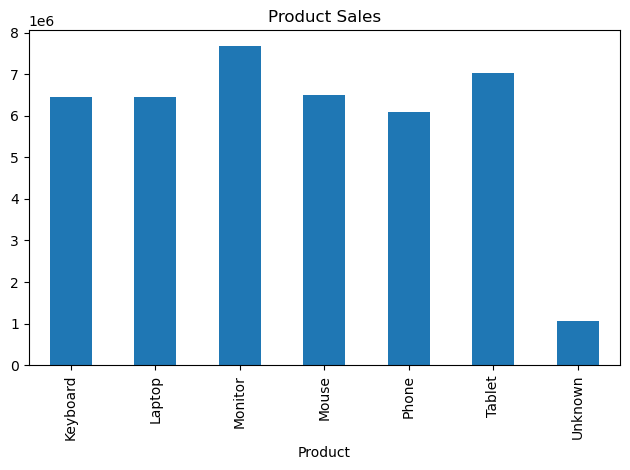

In [48]:
product_sales.plot(kind="bar")

plt.title("Product Sales")
plt.tight_layout()

plt.savefig("../Images/Product_sales.png")

plt.show()

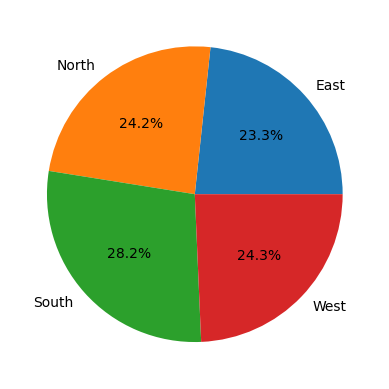

In [49]:
region_sales.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.savefig("../Images/Region_sales.png")

plt.show()

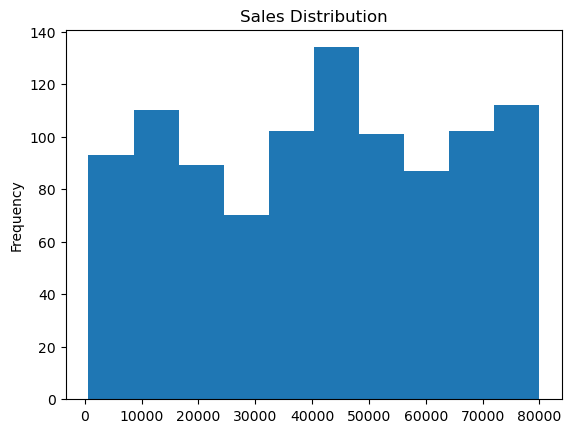

In [50]:
df["Sales"].plot(kind="hist", bins=10)

plt.title("Sales Distribution")

plt.savefig("../Images/Sales_distribution.png")

plt.show()